<a href="https://colab.research.google.com/github/salonisngh/DEEP_LEARNING/blob/main/monthly_beer_production_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

roll_no = "102317246"

digits = [int(d) for d in roll_no]

window_size = sum(digits) % 10 + 8
prediction_horizon = int(roll_no[-2:]) % 3 + 1
hidden_size = int(roll_no[:3]) % 16 + 8

print("Window:", window_size)
print("Horizon:", prediction_horizon)
print("Hidden:", hidden_size)

Window: 14
Horizon: 2
Hidden: 14


In [57]:
import pandas as pd
import os
file_path = './monthly-beer-production-in-austr.csv' # Assuming the file is extracted to the current directory


df = pd.read_csv(file_path, parse_dates=['Month'], index_col='Month')

# MinMaxScaler is already imported in cell sPYMMd-PAFdN
scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(df.values)

print(scaled_data.shape)

data = scaled_data

(476, 1)


In [58]:
def create_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

X, y = create_windows(data, window_size, prediction_horizon)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).squeeze(-1)

# chronological split
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [59]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        x = x.squeeze(-1)
        return self.net(x)

In [60]:
class CustomRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wxh = nn.Linear(1, hidden_size)
        self.Whh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size).to(device)

        for t in range(seq_len):
            h = torch.tanh(self.Wxh(x[:, t, :]) + self.Whh(h))

        return self.fc(h)

In [61]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [62]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, hidden_size)
        # Set batch_first=True to resolve the UserWarning and align with typical batching
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = self.embedding(x)
        # With batch_first=True, input to transformer is already (batch_size, seq_len, features)
        # so no need to permute
        out = self.transformer(x)
        # Extract the output for the last token in each sequence
        out = out[:, -1, :]
        return self.fc(out)

In [63]:
def train_model(model, epochs=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        out = model(X_train.to(device))
        loss = loss_fn(out, y_train.to(device))
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return losses

In [64]:
def evaluate(model):
    model.eval()
    preds = model(X_test.to(device)).detach().cpu().numpy()
    true = y_test.numpy()

    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mse)

    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return preds, true

In [65]:
def plot_results(losses, preds, true):
    plt.figure()
    plt.plot(losses)
    plt.title("Training Loss")

    plt.figure()
    plt.plot(true.flatten(), label="Actual")
    plt.plot(preds.flatten(), label="Predicted")
    plt.legend()


===== MLP =====
Epoch 1, Loss: 0.5884
Epoch 2, Loss: 0.5760
Epoch 3, Loss: 0.5639
Epoch 4, Loss: 0.5519
Epoch 5, Loss: 0.5401
Epoch 6, Loss: 0.5286
Epoch 7, Loss: 0.5172
Epoch 8, Loss: 0.5060
Epoch 9, Loss: 0.4950
Epoch 10, Loss: 0.4841
MSE: 0.6416676044464111
MAE: 0.7875587940216064
RMSE: 0.8010415747303077

===== RNN =====
Epoch 1, Loss: 0.7300
Epoch 2, Loss: 0.7039
Epoch 3, Loss: 0.6782
Epoch 4, Loss: 0.6528
Epoch 5, Loss: 0.6279
Epoch 6, Loss: 0.6034
Epoch 7, Loss: 0.5793
Epoch 8, Loss: 0.5557
Epoch 9, Loss: 0.5327
Epoch 10, Loss: 0.5102
MSE: 0.6745733022689819
MAE: 0.7396146059036255
RMSE: 0.8213241152364771

===== LSTM =====
Epoch 1, Loss: 0.3123
Epoch 2, Loss: 0.3080
Epoch 3, Loss: 0.3037
Epoch 4, Loss: 0.2994
Epoch 5, Loss: 0.2951
Epoch 6, Loss: 0.2908
Epoch 7, Loss: 0.2866
Epoch 8, Loss: 0.2823
Epoch 9, Loss: 0.2780
Epoch 10, Loss: 0.2737
MSE: 0.36775195598602295
MAE: 0.5132472515106201
RMSE: 0.6064255568377894

===== Transformer =====
Epoch 1, Loss: 0.1918
Epoch 2, Loss: 0.2

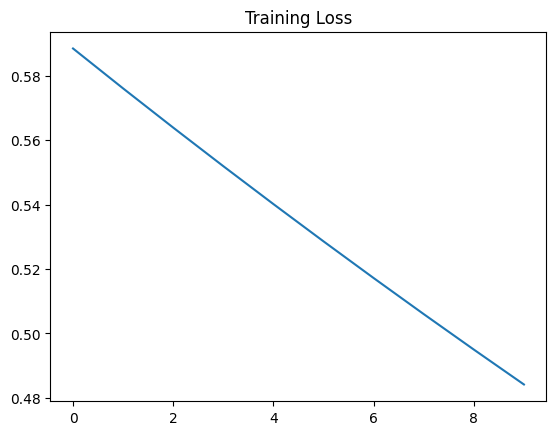

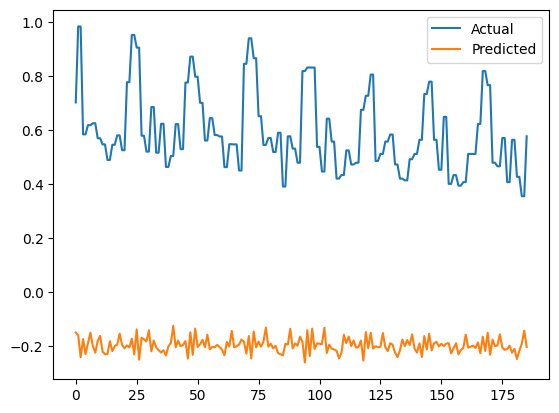

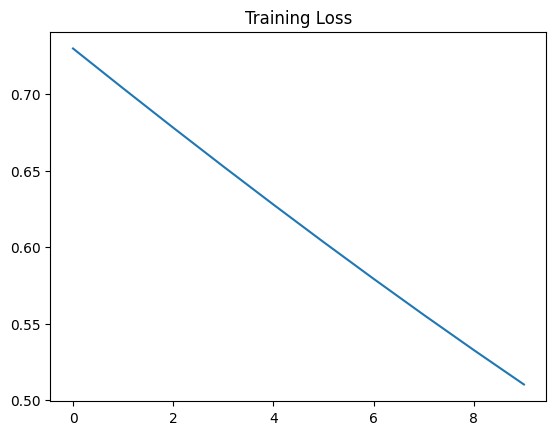

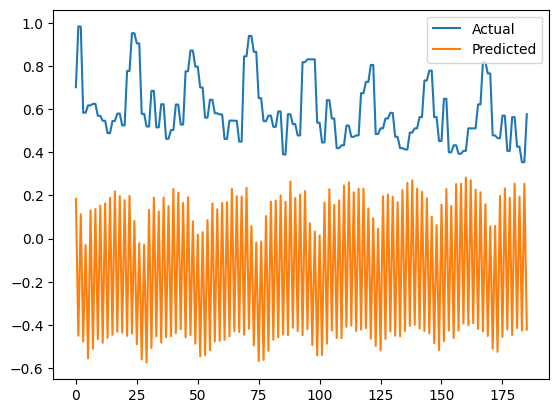

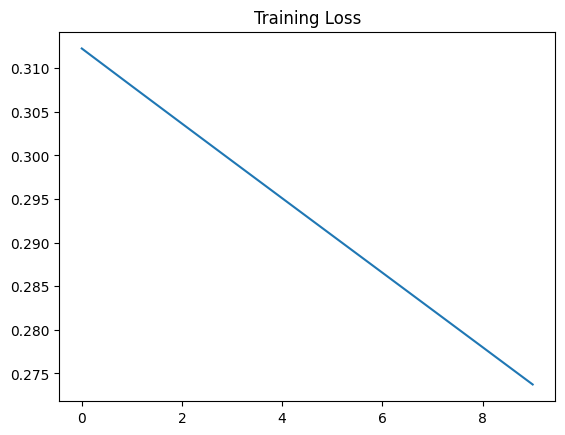

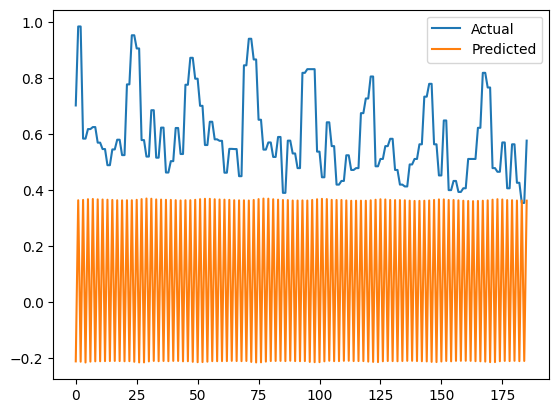

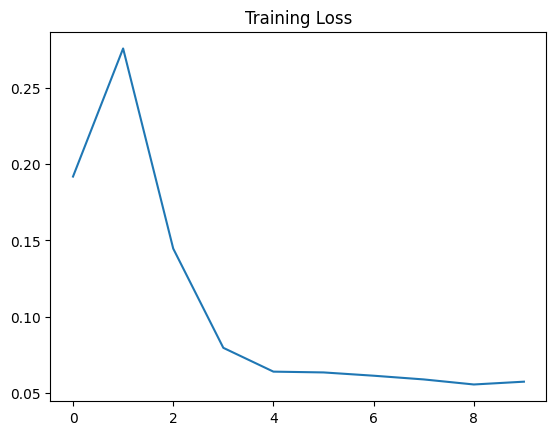

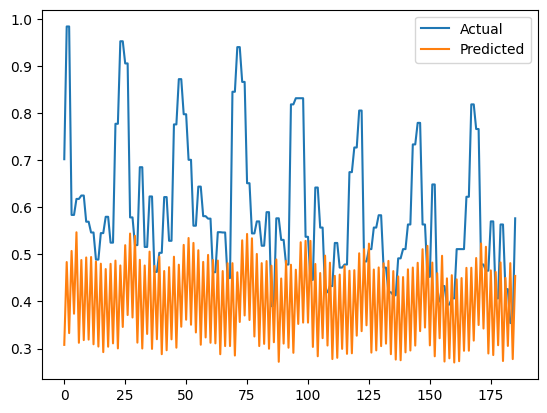

In [66]:
models = {
    "MLP": MLP(),
    "RNN": CustomRNN(),
    "LSTM": LSTMModel(),
    "Transformer": TransformerModel()
}

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    losses = train_model(model)
    preds, true = evaluate(model)
    plot_results(losses, preds, true)
    results[name] = (preds, true)

In [67]:
for factor in [0.5, 2]:
    new_window = int(window_size * factor)

    print(f"\nAblation window: {new_window}")

    X_new, y_new = create_windows(data, new_window, prediction_horizon)

    # repeat training (you can reuse same pipeline)


Ablation window: 7

Ablation window: 28
